## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import re
import json
import ast
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR   = Path('datasets/')
OUTPUT_DIR = Path('outputs/')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Librerías OK')

Librerías OK


## 1. Carga de datasets

In [2]:
# --- US Election 2020 (dataset principal) ---
trump_df = pd.read_csv(
    DATA_DIR / 'hashtag_donaldtrump.csv',
    on_bad_lines='skip',
    engine='python'
)
biden_df = pd.read_csv(
    DATA_DIR / 'hashtag_joebiden.csv',
    on_bad_lines='skip',
    engine='python'
)

trump_df['candidate'] = 'trump'
biden_df['candidate'] = 'biden'

election_df = pd.concat([trump_df, biden_df], ignore_index=True)
print(f'US Election 2020 total: {len(election_df):,} tweets')
print('candidate en election_df:', 'candidate' in election_df.columns)

US Election 2020 total: 1,748,160 tweets
candidate en election_df: True


In [3]:
# --- Datasets secundarios (cargados, pendientes de integrar) ---
twitter_df  = pd.read_csv(DATA_DIR / 'twitter_dataset.csv', on_bad_lines='skip', engine='python')
bot_df      = pd.read_csv(DATA_DIR / 'bot_detection_data.csv', on_bad_lines='skip', engine='python')

with open(DATA_DIR / 'cleaned_twitter_elections_data.json', 'r', encoding='utf-8') as f:
    pakistan_raw = json.load(f)
pakistan_df = pd.DataFrame(pakistan_raw) if isinstance(pakistan_raw, list) else pd.json_normalize(pakistan_raw)

print(f'Twitter general:  {len(twitter_df):,} registros')
print(f'Bot detection:    {len(bot_df):,} registros')
print(f'Pakistan 2018:    {len(pakistan_df):,} registros')

Twitter general:  10,000 registros
Bot detection:    50,000 registros
Pakistan 2018:    29,579 registros


## 2. Limpieza de datos
### 2.1 Selección y renombrado de columnas

In [4]:
COLS_ELECTION = {
    'tweet_id':            'tweet_id',
    'tweet':               'text',
    'created_at':          'created_at',
    'user_id':             'user_id',
    'user_screen_name':    'user_screen_name',
    'user_followers_count':'followers_count',
    'user_join_date':      'user_join_date',
    'likes':               'likes',
    'retweet_count':       'retweet_count',
    'source':              'source',
    'user_location':       'user_location',
    'state':               'state',
    'country':             'country',
    'candidate':           'candidate'
}

df = election_df[[c for c in COLS_ELECTION if c in election_df.columns]].rename(columns=COLS_ELECTION)
print(f'Columnas: {df.columns.tolist()}')
print(f'candidate en df: {"candidate" in df.columns}')

Columnas: ['tweet_id', 'text', 'created_at', 'user_id', 'user_screen_name', 'followers_count', 'user_join_date', 'likes', 'retweet_count', 'source', 'user_location', 'state', 'country', 'candidate']
candidate en df: True


### 2.2 Duplicados

In [5]:
n_before = len(df)
df = df.drop_duplicates(subset='tweet_id')
print(f'Duplicados eliminados: {n_before - len(df):,} | Registros restantes: {len(df):,}')

Duplicados eliminados: 225,215 | Registros restantes: 1,522,945


### 2.3 Valores faltantes

In [6]:
# Mostrar nulos antes de limpiar
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0')

,missing,pct
tweet_id,1,0.00
text,1,0.00
user_id,38,0.00
user_screen_name,34,0.00
followers_count,250,0.02
user_join_date,280,0.02
likes,20,0.00
retweet_count,34,0.00
source,1009,0.07
user_location,462967,30.40


In [7]:
# Eliminar filas sin texto ni timestamp
df = df.dropna(subset=['text', 'created_at'])

# Forzar tipos numéricos antes de rellenar
df['likes']           = pd.to_numeric(df['likes'],           errors='coerce').fillna(0)
df['retweet_count']   = pd.to_numeric(df['retweet_count'],   errors='coerce').fillna(0)
df['followers_count'] = pd.to_numeric(df['followers_count'], errors='coerce').fillna(0)

# Rellenar opcionales
df['user_location'] = df['user_location'].fillna('unknown')
df['state']         = df['state'].fillna('unknown')
df['country']       = df['country'].fillna('unknown')
df['source']        = df['source'].fillna('unknown')

print(f'Registros finales: {len(df):,}')

Registros finales: 1,522,944


## 3. Normalización temporal

In [8]:
df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
df = df.dropna(subset=['created_at'])

df['date']        = df['created_at'].dt.date
df['hour']        = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek
df['week']        = df['created_at'].dt.isocalendar().week.astype(int)
df['hour_window'] = df['created_at'].dt.floor('1h')

print(f'Rango temporal: {df["created_at"].min().date()} → {df["created_at"].max().date()}')

Rango temporal: 2020-10-15 → 2020-11-08


In [9]:
if 'user_join_date' in df.columns:
    df['user_join_date']    = pd.to_datetime(df['user_join_date'], utc=True, errors='coerce')
    df['account_age_days']  = (df['created_at'] - df['user_join_date']).dt.days.clip(lower=0)
else:
    df['account_age_days'] = np.nan

print('account_age_days OK')

account_age_days OK


## 4. Preprocesamiento textual

In [10]:
tokenizer  = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=False)
lemmatizer = WordNetLemmatizer()
STOP_EN    = set(stopwords.words('english'))

def extract_hashtags(text):
    return re.findall(r'#(\w+)', str(text).lower())

def extract_mentions(text):
    return re.findall(r'@(\w+)', str(text).lower())

def is_retweet(text):
    return str(text).strip().startswith('RT @')

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'RT\s@\w+:', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s#]', '', text)
    tokens = tokenizer.tokenize(text)
    tokens = [
        lemmatizer.lemmatize(t) for t in tokens
        if t not in STOP_EN and len(t) > 2 and not t.startswith('#')
    ]
    return ' '.join(tokens)

print('Funciones de texto definidas')

Funciones de texto definidas


In [11]:
df['hashtags']  = df['text'].apply(extract_hashtags)
df['mentions']  = df['text'].apply(extract_mentions)
df['is_retweet']= df['text'].apply(is_retweet).astype(int)
df['n_hashtags']= df['hashtags'].apply(len)
df['n_mentions']= df['mentions'].apply(len)

print('Limpiando texto (puede tardar unos minutos)...')
df['text_clean'] = df['text'].apply(clean_text)
print('Texto limpiado')

Limpiando texto (puede tardar unos minutos)...
Texto limpiado


## 5. Feature Engineering
### 5.1 Actividad por cuenta

In [12]:
df['likes']         = pd.to_numeric(df['likes'],         errors='coerce').fillna(0)
df['retweet_count'] = pd.to_numeric(df['retweet_count'], errors='coerce').fillna(0)
df['n_hashtags']    = pd.to_numeric(df['n_hashtags'],    errors='coerce').fillna(0)

user_activity = (
    df.groupby('user_id')
    .agg(
        total_tweets  =('tweet_id',    'count'),
        total_retweets=('is_retweet',  'sum'),
        unique_days   =('date',        'nunique'),
        avg_likes     =('likes',       'mean'),
        avg_rt        =('retweet_count','mean'),
        avg_hashtags  =('n_hashtags',  'mean'),
    )
    .reset_index()
)
user_activity['retweet_ratio'] = (
    user_activity['total_retweets'] / user_activity['total_tweets'].clip(lower=1)
)

df = df.merge(user_activity, on='user_id', how='left')
print(f'Cuentas únicas: {len(user_activity):,}')

Cuentas únicas: 483,189


### 5.2 Densidad temporal por ventana de 1 hora

In [13]:
window_activity = (
    df.groupby('hour_window')
    .agg(
        tweets_in_window      =('tweet_id',   'count'),
        unique_users_in_window=('user_id',    'nunique'),
        rt_in_window          =('is_retweet', 'sum'),
    )
    .reset_index()
)
window_activity['rt_ratio_window'] = (
    window_activity['rt_in_window'] / window_activity['tweets_in_window'].clip(lower=1)
)

df = df.merge(window_activity, on='hour_window', how='left')
print('Features de ventana temporal creadas')

Features de ventana temporal creadas


### 5.3 Muestra estratificada

In [14]:
SAMPLE_N = 200_000

trump_sample = df[df['candidate'] == 'trump'].sample(
    min(len(df[df['candidate'] == 'trump']), SAMPLE_N // 2), random_state=42)
biden_sample = df[df['candidate'] == 'biden'].sample(
    min(len(df[df['candidate'] == 'biden']), SAMPLE_N // 2), random_state=42)

df_sample = pd.concat([trump_sample, biden_sample]).reset_index(drop=True)

print(f'Muestra de trabajo: {len(df_sample):,} tweets')
print(f'candidate en df_sample: {"candidate" in df_sample.columns}')
print(df_sample['candidate'].value_counts())

Muestra de trabajo: 200,000 tweets
candidate en df_sample: True
candidate
trump    100000
biden    100000
Name: count, dtype: int64


### 5.4 Vectorización TF-IDF

In [15]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True
)
tfidf_matrix = tfidf.fit_transform(df_sample['text_clean'])
print(f'Matriz TF-IDF: {tfidf_matrix.shape}')

Matriz TF-IDF: (200000, 5000)


### 5.5 Feature tabular escalada

In [16]:
NUMERIC_FEATURES = [
    'followers_count', 'likes', 'retweet_count',
    'n_hashtags', 'n_mentions', 'is_retweet',
    'hour', 'day_of_week', 'account_age_days',
    'total_tweets', 'retweet_ratio', 'avg_likes',
    'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window',
]

# Usar solo las que existen
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df_sample.columns]
print(f'Features disponibles: {NUMERIC_FEATURES}')

features_df     = df_sample[NUMERIC_FEATURES].fillna(0)
scaler          = MinMaxScaler()
features_scaled = scaler.fit_transform(features_df)
features_scaled_df = pd.DataFrame(features_scaled, columns=NUMERIC_FEATURES)

print(f'Feature matrix: {features_scaled_df.shape}')
features_scaled_df.describe().T[['mean', 'std', 'min', 'max']]

Features disponibles: ['followers_count', 'likes', 'retweet_count', 'n_hashtags', 'n_mentions', 'is_retweet', 'hour', 'day_of_week', 'account_age_days', 'total_tweets', 'retweet_ratio', 'avg_likes', 'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window']
Feature matrix: (200000, 15)


,mean,std,min,max
followers_count,0.000279,0.004656,0.0,1.0
likes,0.000235,0.005073,0.0,1.0
retweet_count,0.000177,0.004543,0.0,1.0
n_hashtags,0.095218,0.087246,0.0,1.0
n_mentions,0.013535,0.035903,0.0,1.0
is_retweet,0.000125,0.011180,0.0,1.0
hour,0.540038,0.311537,0.0,1.0
day_of_week,0.578211,0.307024,0.0,1.0
account_age_days,0.428104,0.289498,0.0,1.0
total_tweets,0.037266,0.096656,0.0,1.0


## 6. Detección preliminar de anomalías

In [17]:
p95 = window_activity['tweets_in_window'].quantile(0.95)
p99 = window_activity['tweets_in_window'].quantile(0.99)
print(f'Tweets por ventana — P95: {p95:.0f} | P99: {p99:.0f}')

burst_windows = window_activity[window_activity['tweets_in_window'] >= p95].copy()
print(f'Ventanas con burst (>= P95): {len(burst_windows):,}')
burst_windows.sort_values('tweets_in_window', ascending=False).head(10)

Tweets por ventana — P95: 7170 | P99: 14661
Ventanas con burst (>= P95): 30


,hour_window,tweets_in_window,unique_users_in_window,rt_in_window,rt_ratio_window
569,2020-11-07 17:00:00+00:00,46416,39072,4,0.000086
568,2020-11-07 16:00:00+00:00,38179,32747,1,0.000026
570,2020-11-07 18:00:00+00:00,28653,24302,7,0.000244
571,2020-11-07 19:00:00+00:00,19022,16157,4,0.000210
194,2020-10-23 02:00:00+00:00,17445,10188,2,0.000115
193,2020-10-23 01:00:00+00:00,16199,8467,0,0.000000
572,2020-11-07 20:00:00+00:00,14645,12184,1,0.000068
573,2020-11-07 21:00:00+00:00,12708,10498,0,0.000000
487,2020-11-04 07:00:00+00:00,12387,9231,0,0.000000
577,2020-11-08 01:00:00+00:00,12343,9458,0,0.000000


## 7. Guardado de artefactos (A3)

In [18]:
df_sample.to_csv(OUTPUT_DIR / 'df_processed_sample.csv', index=False)
features_scaled_df.to_csv(OUTPUT_DIR / 'features_scaled.csv', index=False)
burst_windows.to_csv(OUTPUT_DIR / 'burst_windows.csv', index=False)

import scipy.sparse as sp
sp.save_npz(OUTPUT_DIR / 'tfidf_matrix.npz', tfidf_matrix)

print('Artefactos guardados en outputs/')

Artefactos guardados en outputs/


## 8. Resumen general del dataset

In [19]:
print('=== Resumen general ===')
print(f"Tweets totales:        {len(df_sample):,}")
print(f"Cuentas únicas:        {df_sample['user_id'].nunique():,}")
print(f"Período:               {df_sample['created_at'].min().date()} → {df_sample['created_at'].max().date()}")
print(f"Retweets:              {df_sample['is_retweet'].sum():,} ({df_sample['is_retweet'].mean()*100:.1f}%)")
print(f"Tweets con hashtag:    {(df_sample['n_hashtags'] > 0).sum():,} ({(df_sample['n_hashtags'] > 0).mean()*100:.1f}%)")
print()
print('--- Por candidato ---')
print(df_sample['candidate'].value_counts())

=== Resumen general ===
Tweets totales:        200,000
Cuentas únicas:        116,495
Período:               2020-10-15 → 2020-11-08
Retweets:              25 (0.0%)
Tweets con hashtag:    199,984 (100.0%)

--- Por candidato ---
candidate
trump    100000
biden    100000
Name: count, dtype: int64


In [20]:
cols_desc = ['likes', 'retweet_count', 'followers_count', 'n_hashtags',
             'n_mentions', 'account_age_days', 'total_tweets', 'retweet_ratio']
cols_desc = [c for c in cols_desc if c in df_sample.columns]
df_sample[cols_desc].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
likes,200000.0,9.00,194.03,0.0,0.0,0.0,2.0,38248.0
retweet_count,200000.0,2.02,51.83,0.0,0.0,0.0,0.0,11407.0
followers_count,200000.0,22966.34,383738.79,0.0,74.0,423.0,2009.0,82417099.0
n_hashtags,200000.0,3.81,3.49,0.0,2.0,3.0,5.0,40.0
n_mentions,200000.0,0.68,1.80,0.0,0.0,0.0,1.0,50.0
account_age_days,199969.0,2238.05,1513.07,0.0,676.0,2427.0,3622.0,5227.0
total_tweets,199999.0,50.38,130.68,1.0,2.0,8.0,37.0,1352.0
retweet_ratio,199999.0,0.00,0.01,0.0,0.0,0.0,0.0,1.0


## 9. Distribución temporal
### 9.1 Tweets por día

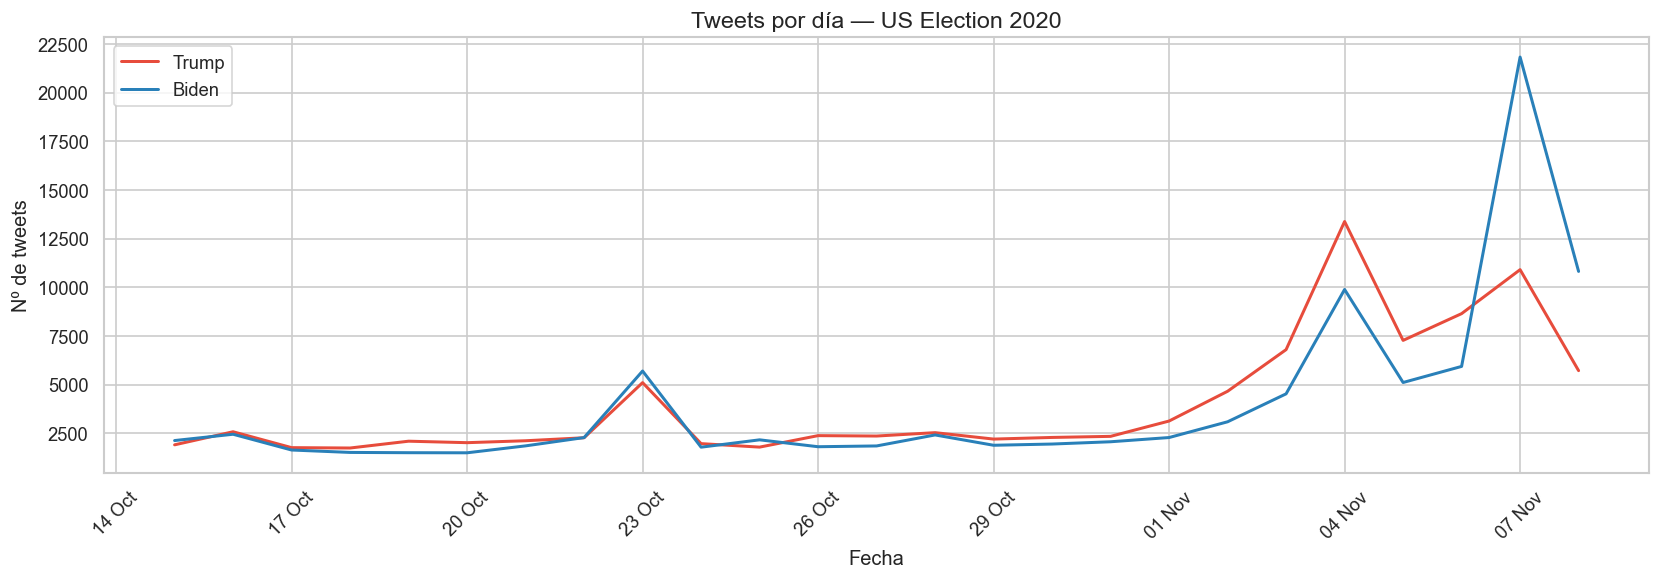

In [21]:
daily = df_sample.groupby(['date', 'candidate']).size().reset_index(name='tweets')
daily['date'] = pd.to_datetime(daily['date'])

fig, ax = plt.subplots(figsize=(14, 5))
for cand, color in [('trump', '#E74C3C'), ('biden', '#2980B9')]:
    d = daily[daily['candidate'] == cand]
    ax.plot(d['date'], d['tweets'], label=cand.capitalize(), color=color, linewidth=1.8)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title('Tweets por día — US Election 2020', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Nº de tweets')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_tweets_por_dia.png')
plt.show()

### 9.2 Tweets por hora del día

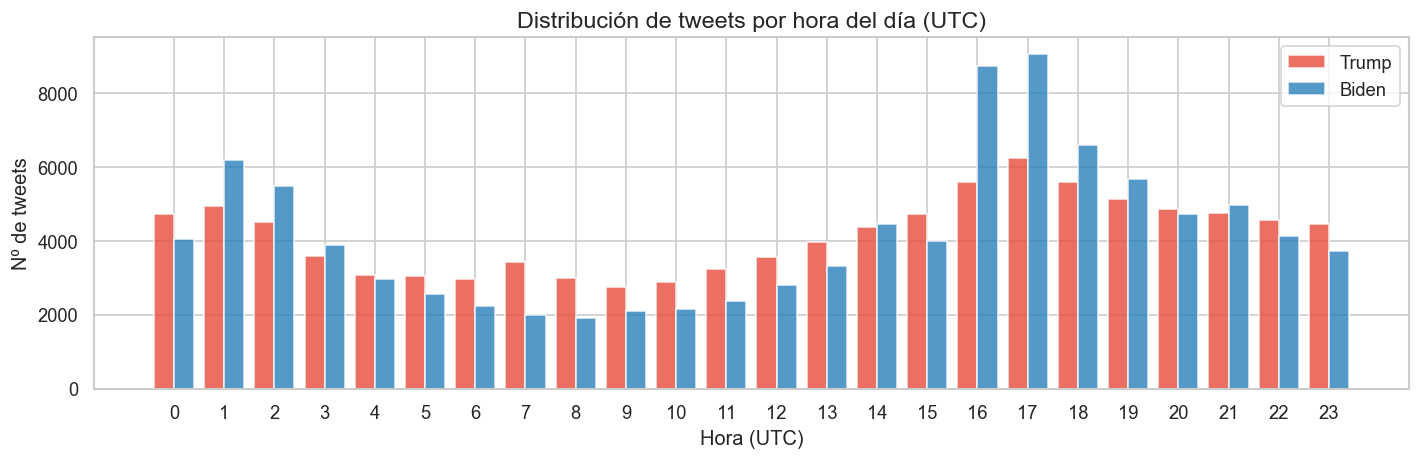

In [22]:
hourly = df_sample.groupby(['hour', 'candidate']).size().reset_index(name='tweets')

fig, ax = plt.subplots(figsize=(12, 4))
for cand, color in [('trump', '#E74C3C'), ('biden', '#2980B9')]:
    d = hourly[hourly['candidate'] == cand]
    ax.bar(d['hour'] + (0.2 if cand == 'biden' else -0.2),
           d['tweets'], width=0.4, label=cand.capitalize(), color=color, alpha=0.8)

ax.set_title('Distribución de tweets por hora del día (UTC)', fontsize=14)
ax.set_xlabel('Hora (UTC)')
ax.set_ylabel('Nº de tweets')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_tweets_por_hora.png')
plt.show()

### 9.3 Mapa de calor: actividad hora × día de la semana

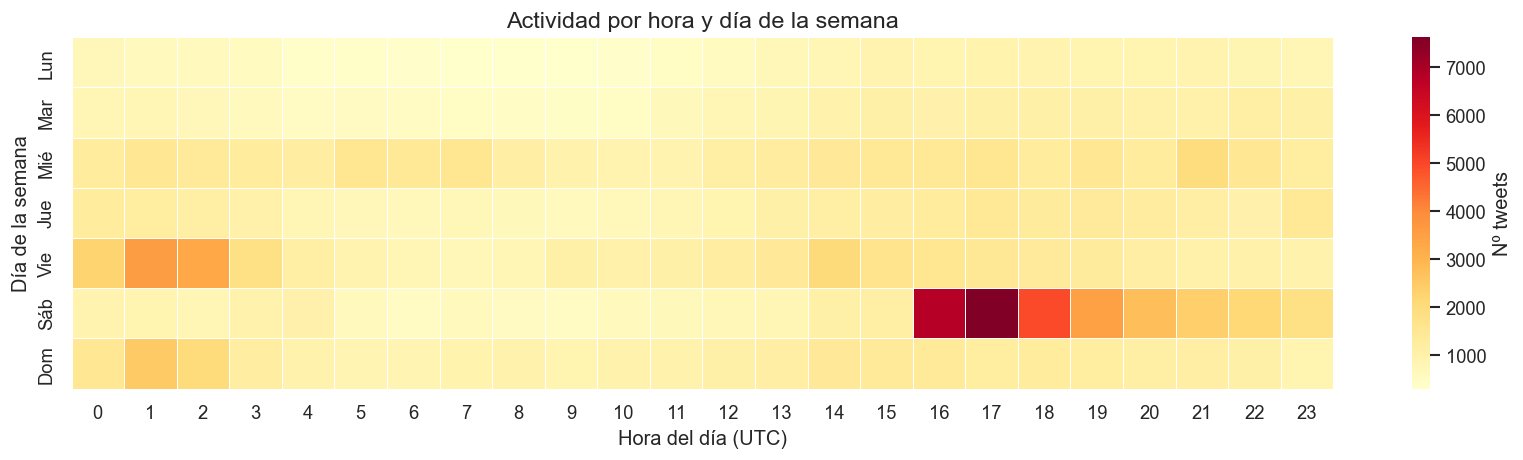

In [23]:
heatmap_data = df_sample.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
heatmap_data.index = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3, cbar_kws={'label': 'Nº tweets'})
ax.set_title('Actividad por hora y día de la semana', fontsize=14)
ax.set_xlabel('Hora del día (UTC)')
ax.set_ylabel('Día de la semana')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_heatmap_hora_dia.png')
plt.show()

### 9.4 Ventanas con burst de actividad (top 20)

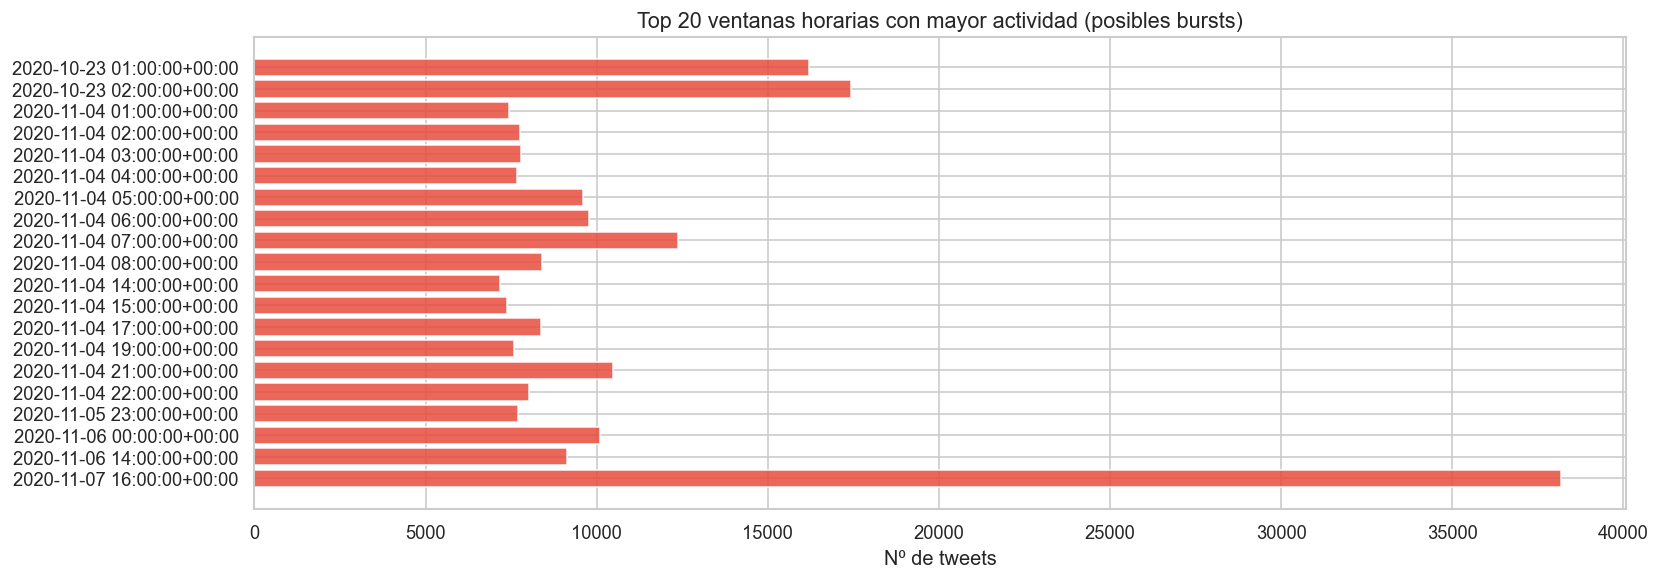

In [24]:
top20 = burst_windows.head(20)
fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(top20['hour_window'].astype(str), top20['tweets_in_window'], color='#E74C3C', alpha=0.85)
ax.set_title('Top 20 ventanas horarias con mayor actividad (posibles bursts)', fontsize=13)
ax.set_xlabel('Nº de tweets')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_burst_windows.png')
plt.show()

## 10. Análisis de cuentas
### 10.1 Distribución de tweets por cuenta

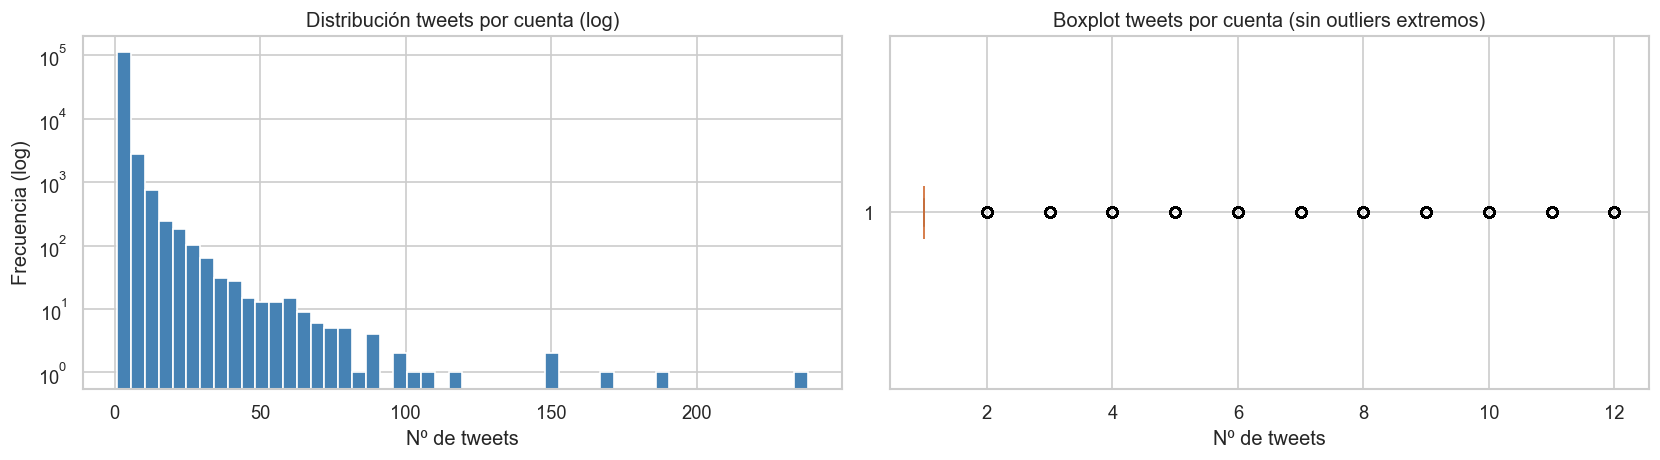

Cuentas con 1 tweet:       90,115
Cuentas con > 50 tweets:   78
Cuentas con > 100 tweets:  8


In [25]:
tweets_per_user = df_sample.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(tweets_per_user, bins=50, color='steelblue', edgecolor='white', log=True)
axes[0].set_title('Distribución tweets por cuenta (log)', fontsize=12)
axes[0].set_xlabel('Nº de tweets')
axes[0].set_ylabel('Frecuencia (log)')

axes[1].boxplot(tweets_per_user.clip(upper=tweets_per_user.quantile(0.99)),
                vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot tweets por cuenta (sin outliers extremos)', fontsize=12)
axes[1].set_xlabel('Nº de tweets')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_tweets_por_cuenta.png')
plt.show()

print(f'Cuentas con 1 tweet:       {(tweets_per_user == 1).sum():,}')
print(f'Cuentas con > 50 tweets:   {(tweets_per_user > 50).sum():,}')
print(f'Cuentas con > 100 tweets:  {(tweets_per_user > 100).sum():,}')

### 10.2 Retweet ratio por cuenta

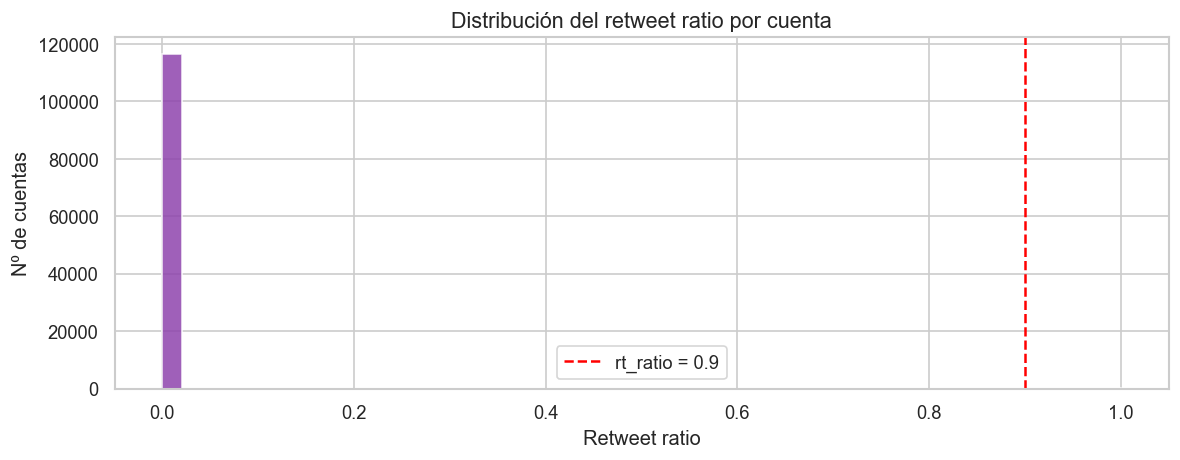

Cuentas con rt_ratio >= 0.9: 14 (0.0%)


In [26]:
user_stats = df_sample.groupby('user_id').agg(
    total=('tweet_id', 'count'),
    rts  =('is_retweet', 'sum')
).reset_index()
user_stats['rt_ratio'] = user_stats['rts'] / user_stats['total'].clip(lower=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(user_stats['rt_ratio'], bins=50, color='#8E44AD', edgecolor='white', alpha=0.85)
ax.axvline(0.9, color='red', linestyle='--', label='rt_ratio = 0.9')
ax.set_title('Distribución del retweet ratio por cuenta', fontsize=13)
ax.set_xlabel('Retweet ratio')
ax.set_ylabel('Nº de cuentas')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_retweet_ratio.png')
plt.show()

high_rt = (user_stats['rt_ratio'] >= 0.9).sum()
print(f'Cuentas con rt_ratio >= 0.9: {high_rt:,} ({high_rt/len(user_stats)*100:.1f}%)')

### 10.3 Antigüedad de cuenta

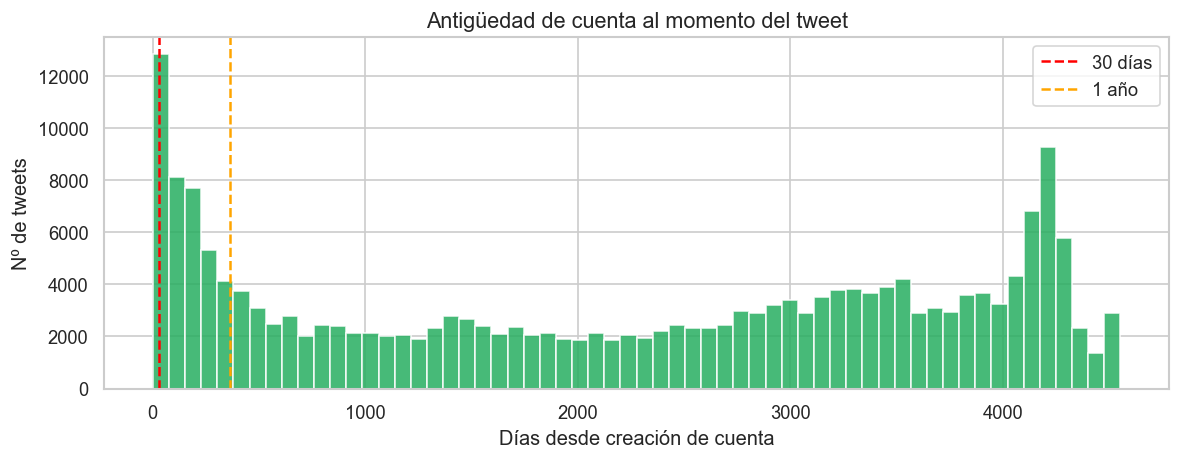

Tweets de cuentas con <= 30 días: 6,824 (3.4%)


In [27]:
if 'account_age_days' in df_sample.columns:
    age = df_sample['account_age_days'].dropna()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(age.clip(upper=age.quantile(0.99)), bins=60, color='#27AE60', edgecolor='white', alpha=0.85)
    ax.axvline(30,  color='red',    linestyle='--', label='30 días')
    ax.axvline(365, color='orange', linestyle='--', label='1 año')
    ax.set_title('Antigüedad de cuenta al momento del tweet', fontsize=13)
    ax.set_xlabel('Días desde creación de cuenta')
    ax.set_ylabel('Nº de tweets')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'eda_antiguedad_cuenta.png')
    plt.show()
    nuevas = (age <= 30).sum()
    print(f'Tweets de cuentas con <= 30 días: {nuevas:,} ({nuevas/len(age)*100:.1f}%)')

## 11. Análisis de contenido
### 11.1 Hashtags más frecuentes

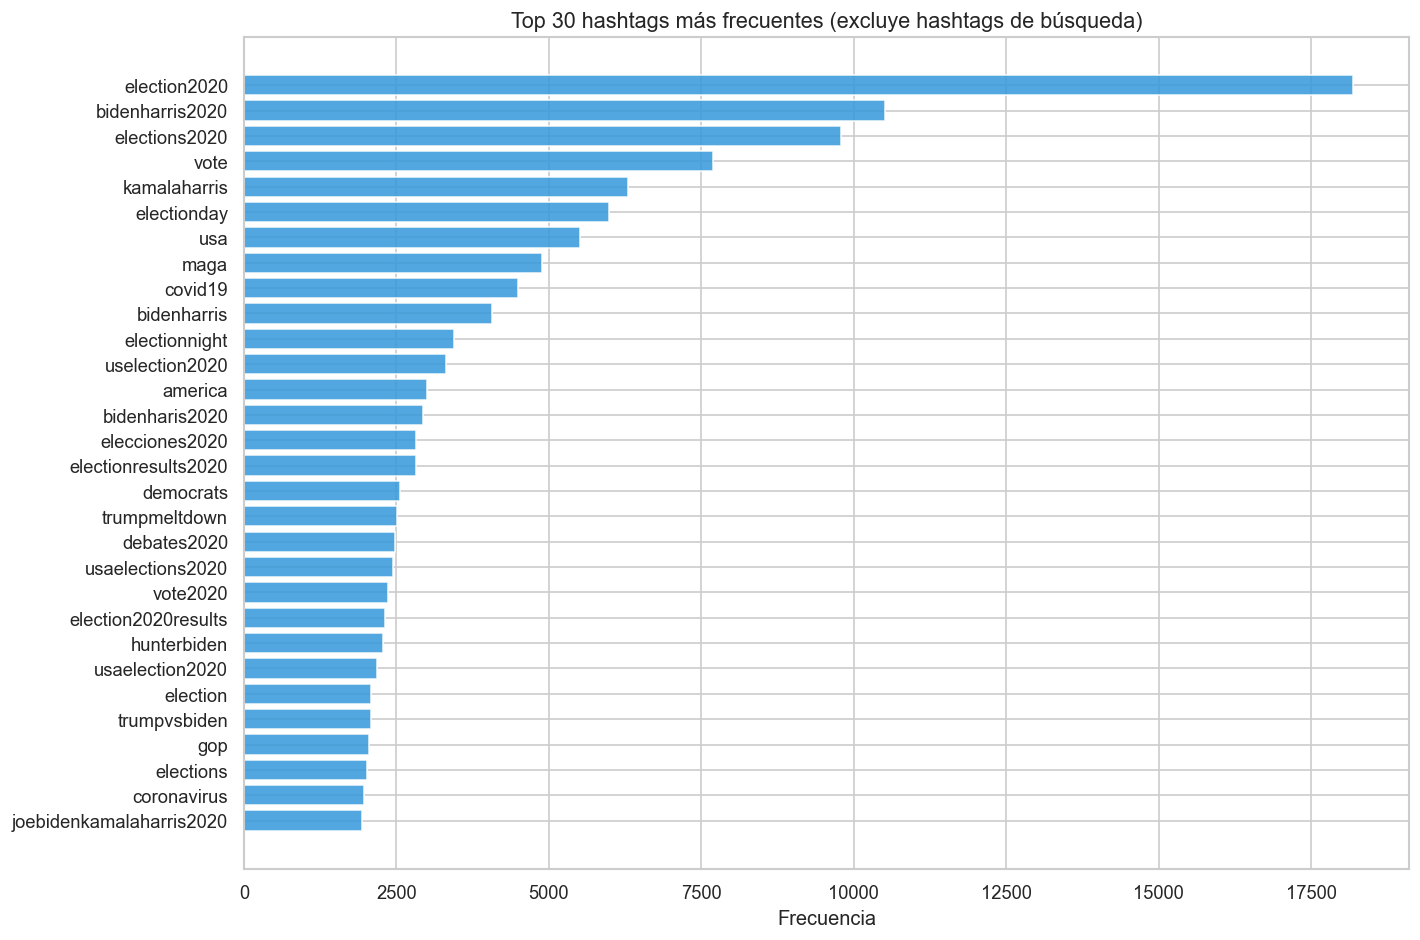

In [28]:
all_hashtags  = [ht for lista in df_sample['hashtags'] for ht in lista]
hashtag_counts = Counter(all_hashtags)
exclude = {'donaldtrump', 'trump', 'joebiden', 'biden', 'trump2020', 'biden2020'}
top_ht  = [(k, v) for k, v in hashtag_counts.most_common(50) if k not in exclude][:30]

labels, values = zip(*top_ht)
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(labels, values, color='#3498DB', alpha=0.85)
ax.invert_yaxis()
ax.set_title('Top 30 hashtags más frecuentes (excluye hashtags de búsqueda)', fontsize=13)
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_top_hashtags.png')
plt.show()

### 11.2 Hashtags por candidato

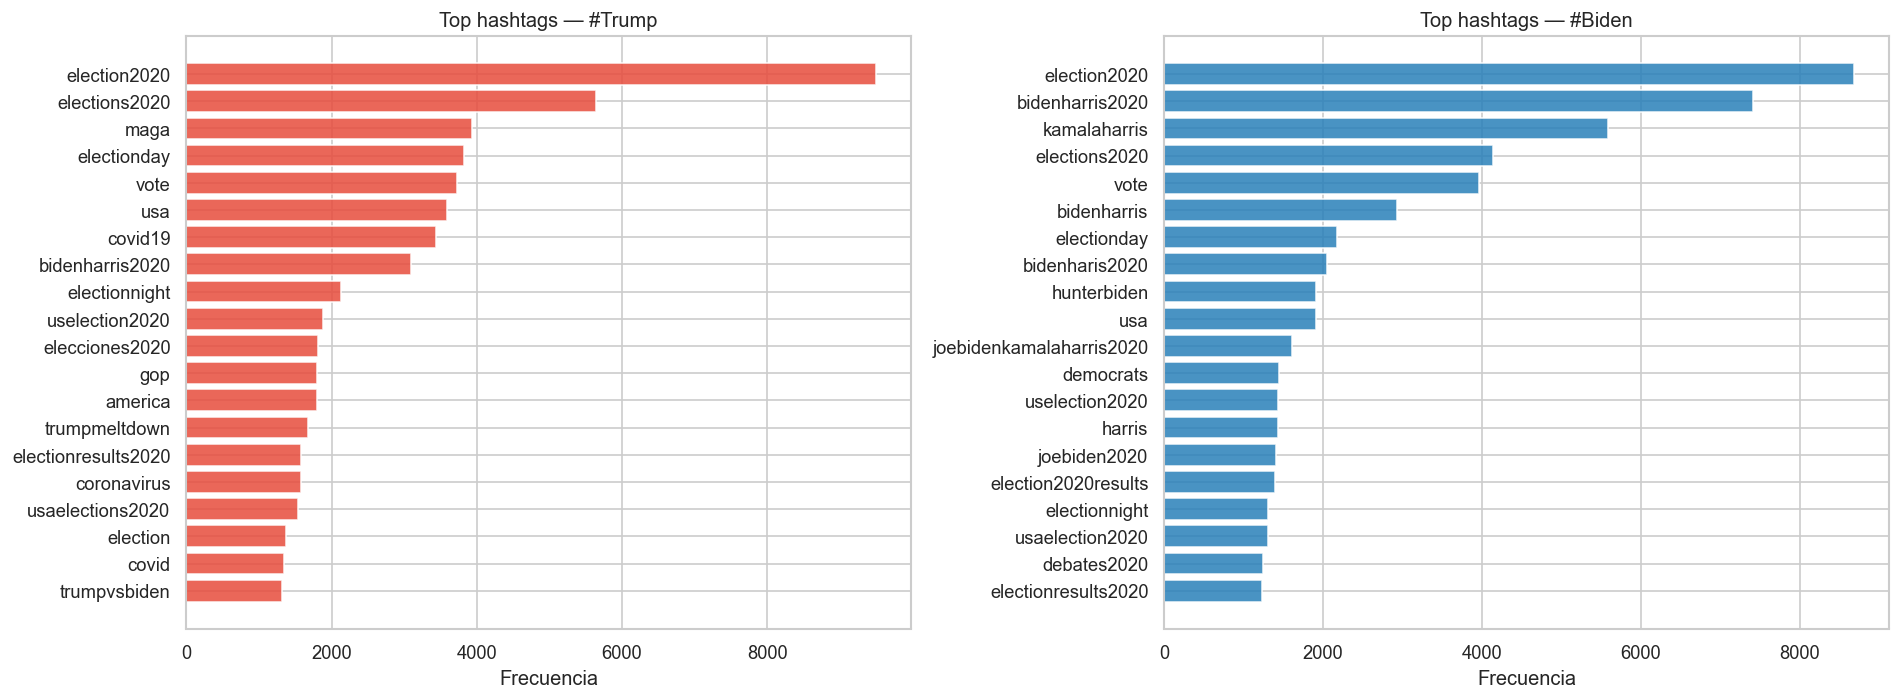

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (cand, color) in zip(axes, [('trump', '#E74C3C'), ('biden', '#2980B9')]):
    ht_cand = [ht for lista in df_sample[df_sample['candidate'] == cand]['hashtags'] for ht in lista]
    counts  = Counter(ht_cand)
    top     = [(k, v) for k, v in counts.most_common(40) if k not in exclude][:20]
    if top:
        lbls, vals = zip(*top)
        ax.barh(lbls, vals, color=color, alpha=0.85)
        ax.invert_yaxis()
    ax.set_title(f'Top hashtags — #{cand.capitalize()}', fontsize=12)
    ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_hashtags_por_candidato.png')
plt.show()

### 11.3 Distribución de likes y retweets

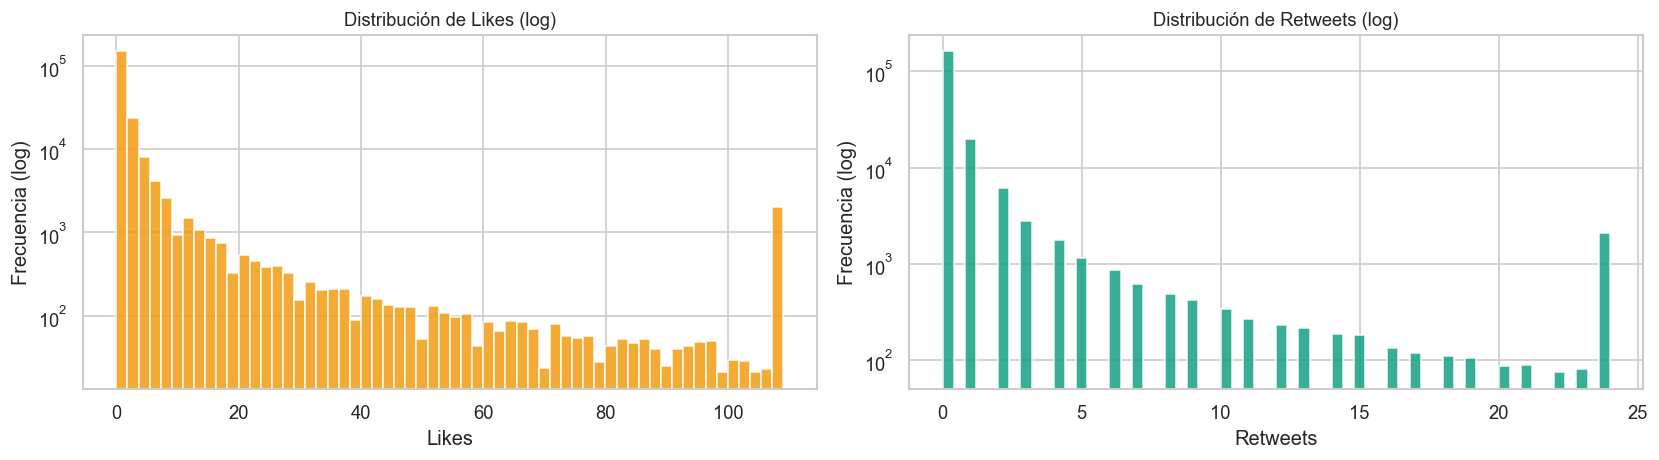

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color, label in [
    (axes[0], 'likes',         '#F39C12', 'Likes'),
    (axes[1], 'retweet_count', '#16A085', 'Retweets')
]:
    data      = df_sample[col].dropna()
    data_clip = data.clip(upper=data.quantile(0.99))
    ax.hist(data_clip, bins=60, color=color, edgecolor='white', alpha=0.85, log=True)
    ax.set_title(f'Distribución de {label} (log)', fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia (log)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_likes_retweets.png')
plt.show()

## 12. Señales de coordinación preliminares
### 12.1 Cuentas que tuitean en múltiples ventanas de burst

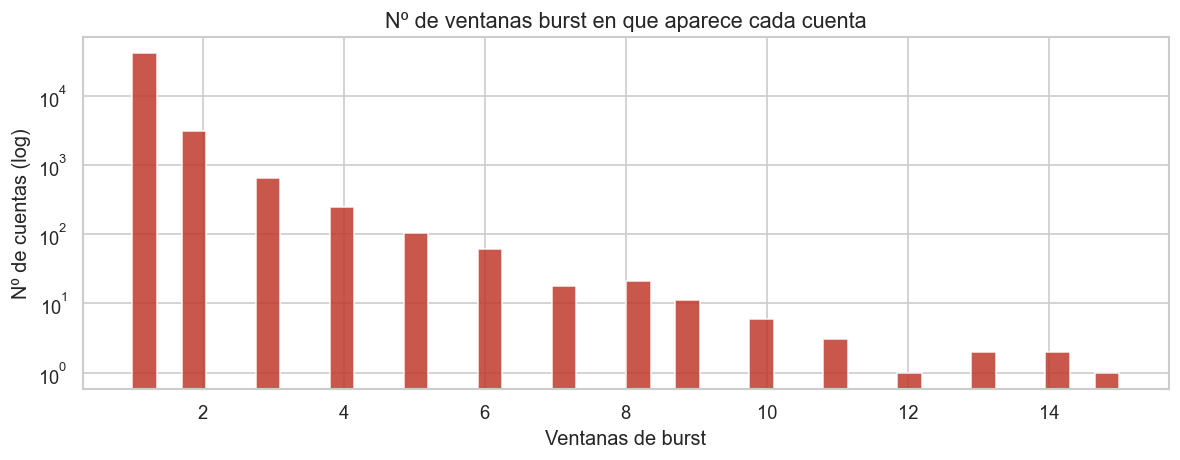

Cuentas en >= 5 ventanas de burst: 227
               user_id  burst_windows_count
 7.042226858621747e+17                   15
           231726084.0                   14
           786625296.0                   14
 8.743729821347594e+17                   13
          2373909360.0                   13
            92356864.0                   12
           152142811.0                   11
           161151263.0                   11
1.0247779165409649e+18                   11
            34639484.0                   10


In [31]:
burst_df = df_sample[df_sample['tweets_in_window'] >= p95]
burst_user_count = burst_df.groupby('user_id')['hour_window'].nunique().reset_index()
burst_user_count.columns = ['user_id', 'burst_windows_count']

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(burst_user_count['burst_windows_count'], bins=40, color='#C0392B', edgecolor='white', alpha=0.85, log=True)
ax.set_title('Nº de ventanas burst en que aparece cada cuenta', fontsize=13)
ax.set_xlabel('Ventanas de burst')
ax.set_ylabel('Nº de cuentas (log)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_cuentas_burst.png')
plt.show()

multi_burst = burst_user_count[burst_user_count['burst_windows_count'] >= 5]
print(f'Cuentas en >= 5 ventanas de burst: {len(multi_burst):,}')
print(burst_user_count.sort_values('burst_windows_count', ascending=False).head(10).to_string(index=False))

### 12.2 Correlación entre variables numéricas

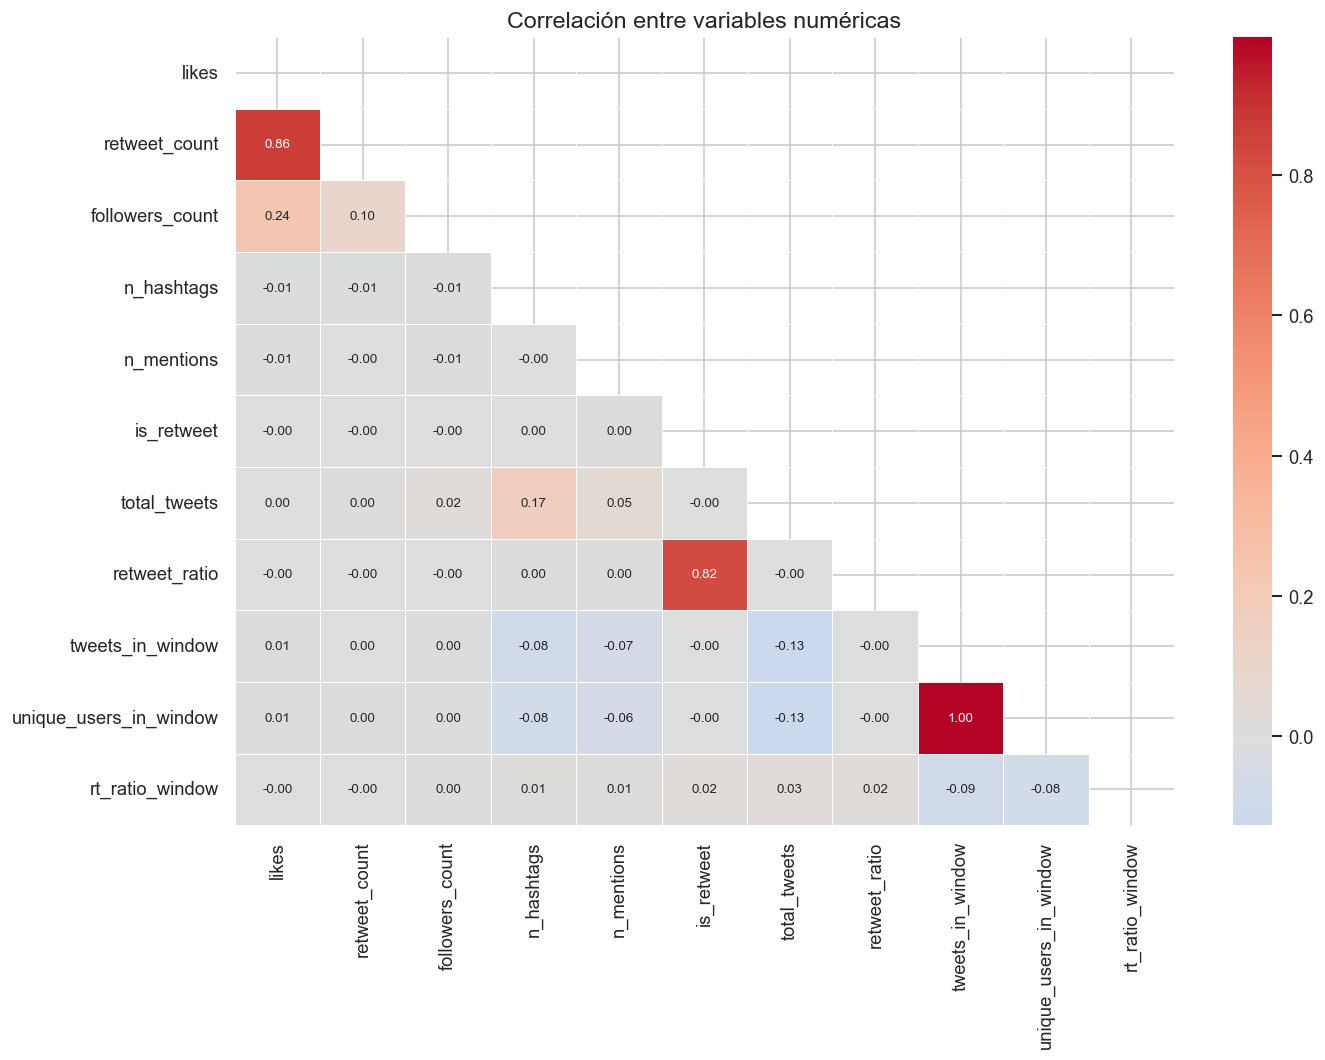

In [32]:
corr_cols = [c for c in [
    'likes', 'retweet_count', 'followers_count', 'n_hashtags',
    'n_mentions', 'is_retweet', 'total_tweets', 'retweet_ratio',
    'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window'
] if c in df_sample.columns]

corr = df_sample[corr_cols].corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlación entre variables numéricas', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_correlacion.png')
plt.show()

### 12.3 Actividad de las top 10 cuentas por volumen

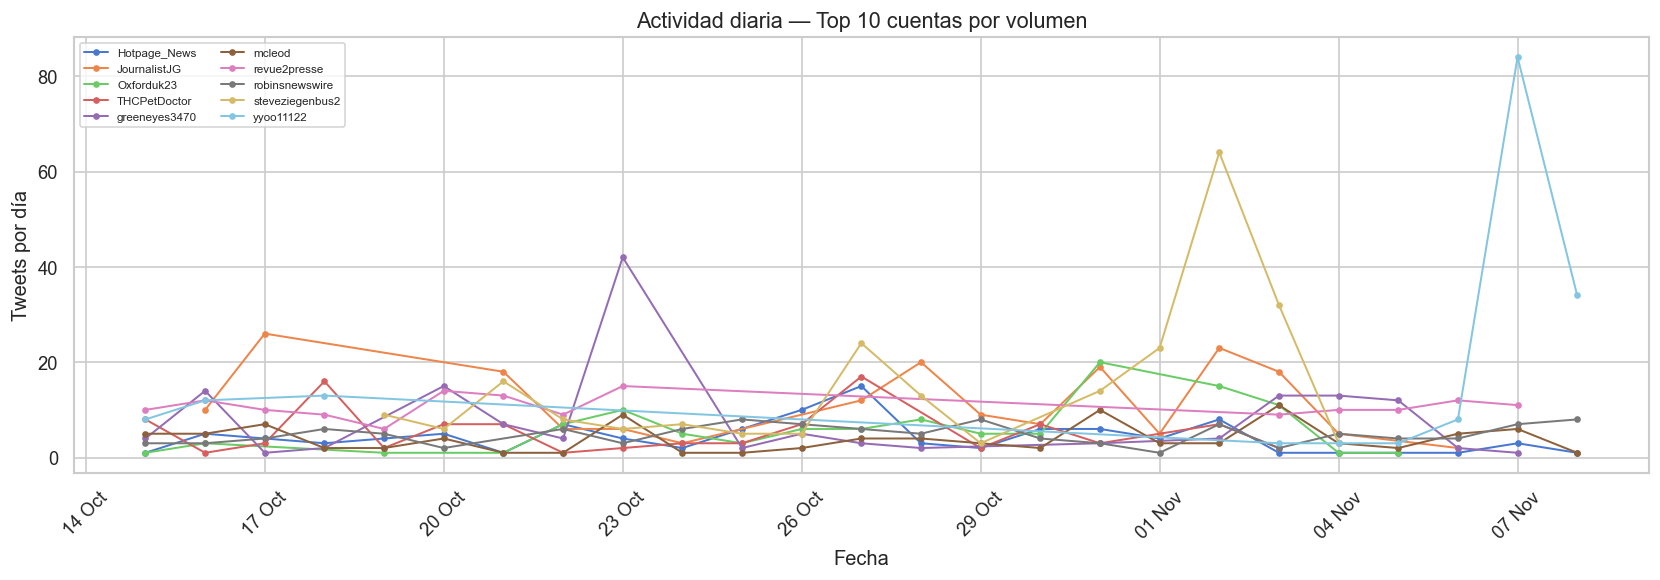

In [33]:
top_users  = df_sample.groupby('user_id').size().nlargest(10).index
top_df     = df_sample[df_sample['user_id'].isin(top_users)].copy()
top_df['user_label'] = top_df['user_screen_name'].fillna(top_df['user_id'].astype(str))

activity = top_df.groupby(['user_label', 'date']).size().reset_index(name='tweets')
activity['date'] = pd.to_datetime(activity['date'])

fig, ax = plt.subplots(figsize=(14, 5))
for user in activity['user_label'].unique():
    d = activity[activity['user_label'] == user]
    ax.plot(d['date'], d['tweets'], marker='o', markersize=3, linewidth=1.2, label=str(user))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title('Actividad diaria — Top 10 cuentas por volumen', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Tweets por día')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_top_cuentas_actividad.png')
plt.show()

---
## Pendientes
- [ ] Completar tabla de hallazgos con observaciones reales
- [ ] Integrar `bot_detection_data.csv` en A6
- [ ] Definir umbral definitivo de burst (P95 vs P99)
- [ ] Pasar `burst_windows` y `multi_burst` como insumo a A5